In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
data = pd.read_excel(r"C:\Users\pgdee\Downloads\2021-2023 FNDDS At A Glance - FNDDS Nutrient Values.xlsx",
    header=1
)

data.head()

,Food code,Main food description,WWEIA Category number,WWEIA Category description,Energy (kcal),Protein (g),Carbohydrate (g),"Sugars, total\n(g)","Fiber, total dietary (g)",Total Fat (g),...,20:1\n(g),22:1\n(g),18:2\n(g),18:3\n(g),18:4\n(g),20:4\n(g),20:5 n-3\n(g),22:5 n-3\n(g),22:6 n-3\n(g),Water\n(g)
0,11100000,"Milk, NFS",1004,"Milk, reduced fat",52,3.33,4.83,4.88,0.0,2.14,...,0.002,0.0,0.074,0.008,0.0,0.003,0.000,0.001,0.0,88.92
1,11111000,"Milk, whole",1002,"Milk, whole",61,3.27,4.63,4.81,0.0,3.20,...,0.004,0.0,0.115,0.013,0.0,0.004,0.001,0.002,0.0,88.10
2,11112110,"Milk, reduced fat (2%)",1004,"Milk, reduced fat",50,3.36,4.90,4.89,0.0,1.90,...,0.002,0.0,0.061,0.007,0.0,0.003,0.000,0.001,0.0,89.10
3,11112210,"Milk, low fat (1%)",1006,"Milk, lowfat",43,3.38,5.18,4.96,0.0,0.95,...,0.001,0.0,0.033,0.004,0.0,0.001,0.000,0.000,0.0,89.70
4,11113000,"Milk, fat free (skim)",1008,"Milk, nonfat",34,3.43,4.92,5.05,0.0,0.08,...,0.000,0.0,0.005,0.000,0.0,0.000,0.000,0.000,0.0,90.80


In [3]:
print("Dataset shape:", data.shape)

print("\nColumn names:")
print(data.columns.tolist())

Dataset shape: (5431, 69)

Column names:
['Food code', 'Main food description', 'WWEIA Category number', 'WWEIA Category description', 'Energy (kcal)', 'Protein (g)', 'Carbohydrate (g)', 'Sugars, total\n(g)', 'Fiber, total dietary (g)', 'Total Fat (g)', 'Fatty acids, total saturated (g)', 'Fatty acids, total monounsaturated (g)', 'Fatty acids, total polyunsaturated (g)', 'Cholesterol (mg)', 'Retinol (mcg)', 'Vitamin A, RAE (mcg_RAE)', 'Carotene, alpha (mcg)', 'Carotene, beta (mcg)', 'Cryptoxanthin, beta (mcg)', 'Lycopene (mcg)', 'Lutein + zeaxanthin (mcg)', 'Thiamin (mg)', 'Riboflavin (mg)', 'Niacin (mg)', 'Vitamin B-6 (mg)', 'Folic acid (mcg)', 'Folate, food (mcg)', 'Folate, DFE (mcg_DFE)', 'Folate, total (mcg)', 'Choline, total (mg)', 'Vitamin B-12 (mcg)', 'Vitamin B-12, added\n(mcg)', 'Vitamin C (mg)', 'Vitamin D (D2 + D3) (mcg)', 'Vitamin E (alpha-tocopherol) (mg)', 'Vitamin E, added\n(mg)', 'Vitamin K (phylloquinone) (mcg)', 'Calcium (mg)', 'Phosphorus (mg)', 'Magnesium (mg)', 'Ir

In [4]:
data = data[[
    "Main food description",
    "Protein (g)",
    "Fiber, total dietary (g)",
    "Vitamin C (mg)",
    "Calcium (mg)",
    "Magnesium (mg)",
    "Zinc",
    "Iron"
]].copy()

data.columns = [
    "Food",
    "Protein",
    "Fiber",
    "Vitamin_C",
    "Calcium",
    "Magnesium",
    "Zinc",
    "Iron"
]

data.head()

KeyError: "['Zinc', 'Iron'] not in index"

In [5]:

iron_column = [col for col in data.columns if "iron" in str(col).lower()][0]
zinc_column = [col for col in data.columns if "zinc" in str(col).lower()][0]

data = data[[
    "Main food description",
    "Protein (g)",
    "Fiber, total dietary (g)",
    "Vitamin C (mg)",
    "Calcium (mg)",
    "Magnesium (mg)",
    zinc_column,
    iron_column
]].copy()

data.columns = [
    "Food",
    "Protein",
    "Fiber",
    "Vitamin_C",
    "Calcium",
    "Magnesium",
    "Zinc",
    "Iron"
]

data.head()

,Food,Protein,Fiber,Vitamin_C,Calcium,Magnesium,Zinc,Iron
0,"Milk, NFS",3.33,0.0,0.1,125,12,0.43,0.0
1,"Milk, whole",3.27,0.0,0.0,123,12,0.42,0.0
2,"Milk, reduced fat (2%)",3.36,0.0,0.2,126,12,0.43,0.0
3,"Milk, low fat (1%)",3.38,0.0,0.0,126,12,0.43,0.0
4,"Milk, fat free (skim)",3.43,0.0,0.0,132,12,0.45,0.0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5431 entries, 0 to 5430
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Food       5431 non-null   object 
 1   Protein    5431 non-null   float64
 2   Fiber      5431 non-null   float64
 3   Vitamin_C  5431 non-null   float64
 4   Calcium    5431 non-null   int64  
 5   Magnesium  5431 non-null   int64  
 6   Zinc       5431 non-null   float64
 7   Iron       5431 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 339.6+ KB


In [7]:
data.isnull().sum()

Food         0
Protein      0
Fiber        0
Vitamin_C    0
Calcium      0
Magnesium    0
Zinc         0
Iron         0
dtype: int64

In [8]:
data.describe()

,Protein,Fiber,Vitamin_C,Calcium,Magnesium,Zinc,Iron
count,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000,5431.000000
mean,8.161322,1.745516,5.673872,72.430860,28.036089,1.112933,1.552744
std,7.777699,2.427976,15.722676,117.220849,40.547830,2.244090,2.909494
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.200000,0.200000,0.000000,14.000000,13.000000,0.340000,0.420000
50%,6.140000,1.100000,0.600000,34.000000,20.000000,0.680000,1.000000
75%,11.525000,2.200000,5.000000,90.500000,28.000000,1.300000,1.870000
max,78.130000,42.800000,560.000000,1375.000000,611.000000,98.860000,64.100000


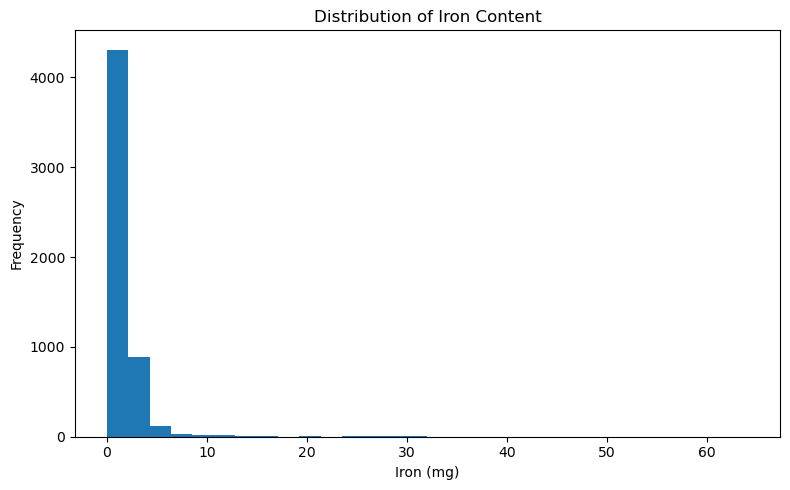

In [9]:
plt.figure(figsize=(8, 5))

plt.hist(data["Iron"], bins=30)

plt.xlabel("Iron (mg)")
plt.ylabel("Frequency")
plt.title("Distribution of Iron Content")

plt.tight_layout()
plt.show()

In [10]:
adult_data = data[
    ~data["Food"].str.contains(
        "baby|toddler|infant",
        case=False,
        na=False
    )
].copy()

In [11]:
top_iron = adult_data.sort_values(
    by="Iron",
    ascending=False
).head(10)

top_iron[["Food", "Iron"]]

,Food,Iron
3084,"Cereal, O's, multigrain",46.58
3064,"Cereal, O's, plain",30.87
3082,"Cereal, oat squares",30.08
3098,"Cereal, other, plain",29.44
3087,"Cereal, K's, plain",29.31
3068,"Cereal, corn squares",28.47
3078,"Cereal, oat bunches",28.22
3072,"Cereal, bran flakes, plain",28.10
3069,"Cereal, corn flakes, plain",28.01
3070,"Cereal, corn puffs",27.99


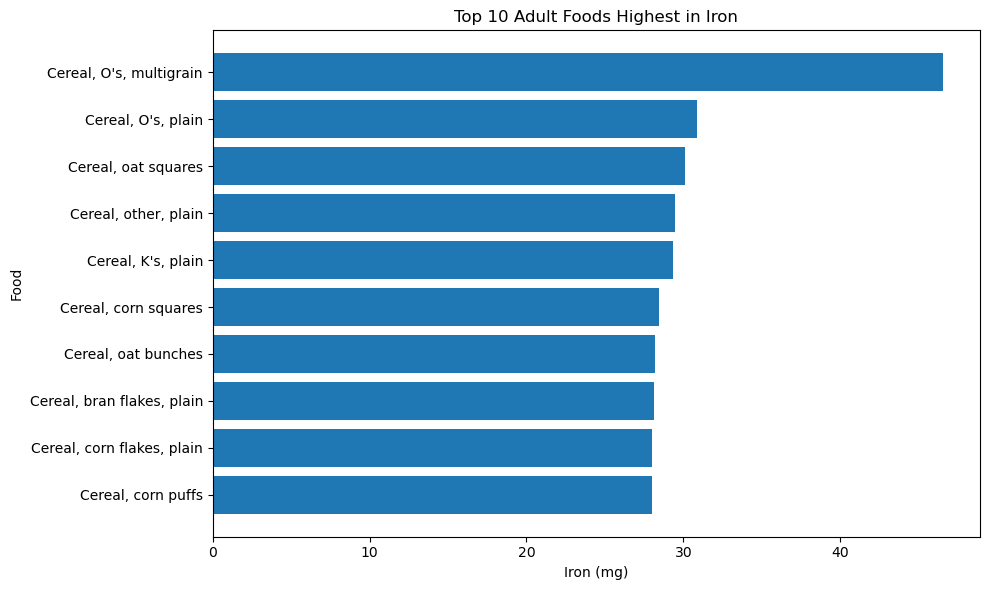

In [12]:
plt.figure(figsize=(10, 6))

plt.barh(top_iron["Food"], top_iron["Iron"])

plt.xlabel("Iron (mg)")
plt.ylabel("Food")
plt.title("Top 10 Adult Foods Highest in Iron")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
correlation = data[[
    "Protein",
    "Fiber",
    "Vitamin_C",
    "Calcium",
    "Magnesium",
    "Zinc",
    "Iron"
]].corr()

print(correlation["Iron"].sort_values(ascending=False))

Iron         1.000000
Magnesium    0.352061
Calcium      0.342981
Fiber        0.340199
Zinc         0.319044
Protein      0.195744
Vitamin_C    0.091320
Name: Iron, dtype: float64


In [14]:
ml_data = adult_data.dropna().copy()

print("Rows available for modeling:", len(ml_data))

Rows available for modeling: 5280


In [15]:
features = [
    "Protein",
    "Fiber",
    "Vitamin_C",
    "Calcium",
    "Magnesium",
    "Zinc"
]

X = ml_data[features]
y = ml_data["Iron"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

In [18]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [19]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

In [20]:
def evaluate_model(y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    return mae, rmse, r2

In [21]:
baseline_results = evaluate_model(
    y_test,
    baseline_predictions
)

linear_results = evaluate_model(
    y_test,
    linear_predictions
)

forest_results = evaluate_model(
    y_test,
    forest_predictions
)

results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_results[0],
        linear_results[0],
        forest_results[0]
    ],
    "RMSE": [
        baseline_results[1],
        linear_results[1],
        forest_results[1]
    ],
    "R²": [
        baseline_results[2],
        linear_results[2],
        forest_results[2]
    ]
})

results

,Model,MAE,RMSE,R²
0,Baseline,1.062835,1.861982,-0.006127
1,Linear Regression,0.790059,1.711015,0.150410
2,Random Forest,0.449497,1.403045,0.428726


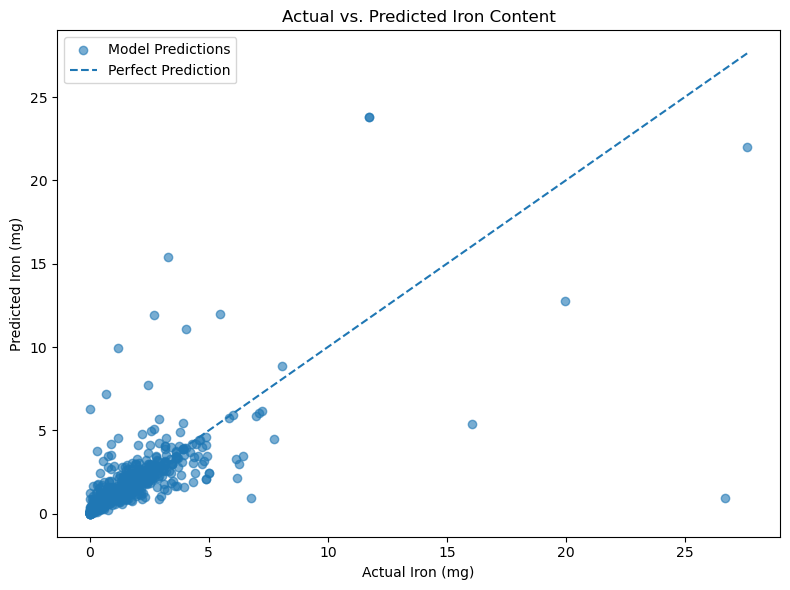

In [22]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    forest_predictions,
    alpha=0.6,
    label="Model Predictions"
)

minimum = min(y_test.min(), forest_predictions.min())
maximum = max(y_test.max(), forest_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Iron (mg)")
plt.ylabel("Predicted Iron (mg)")
plt.title("Actual vs. Predicted Iron Content")

plt.legend()
plt.tight_layout()
plt.show()

In [23]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": forest_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Fiber,0.233421
3,Calcium,0.189774
2,Vitamin_C,0.171634
0,Protein,0.154577
4,Magnesium,0.145489
5,Zinc,0.105106


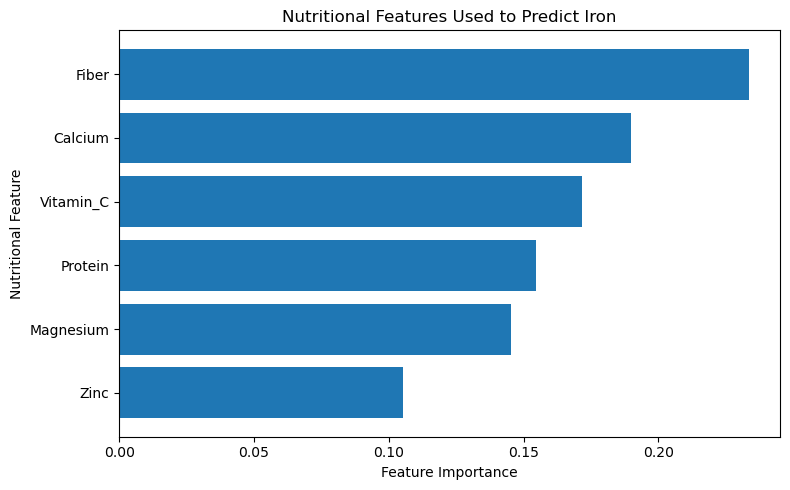

In [24]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Nutritional Feature")
plt.title("Nutritional Features Used to Predict Iron")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()